<a href="https://colab.research.google.com/github/Rupa20052003/CODSOFT/blob/main/my_first_python_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

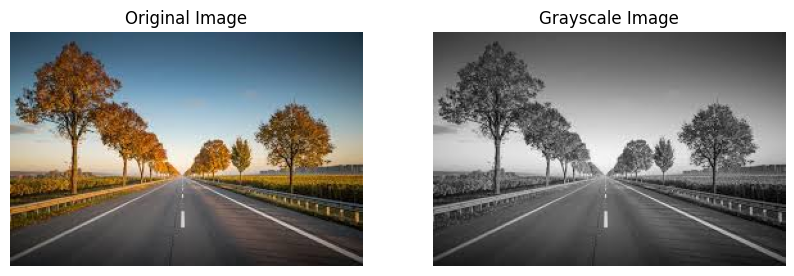

In [21]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/lane detect.jpg'
image = cv2.imread(image_path)

# Convert the image to grayscale (edge detection works best on grayscale images)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original and grayscale images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()

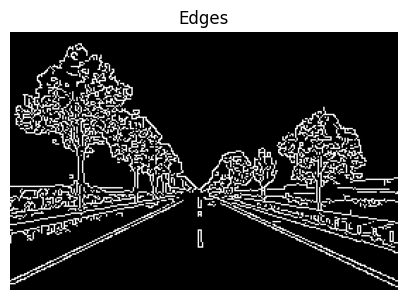

In [22]:
# Apply Canny edge detection
edges = cv2.Canny(gray_image, 100, 200)  # Adjust the thresholds as needed

# Display the edges
plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap='gray')
plt.title('Edges')
plt.axis('off')
plt.show()

# Task
Write Python code to perform lane detection on an image.

## Apply gaussian blur

### Subtask:
Reduce noise in the grayscale image.


**Reasoning**:
Apply Gaussian blur to the grayscale image to reduce noise.



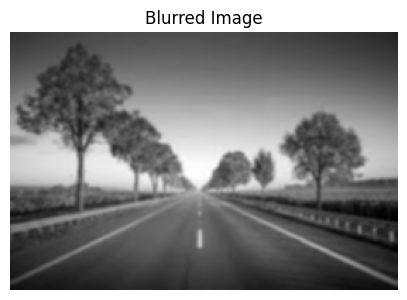

In [23]:
# Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Display the blurred image
plt.figure(figsize=(5, 5))
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.show()

## Apply canny edge detection

### Subtask:
Detect edges in the blurred image.


**Reasoning**:
Apply Canny edge detection to the blurred image and display the result.



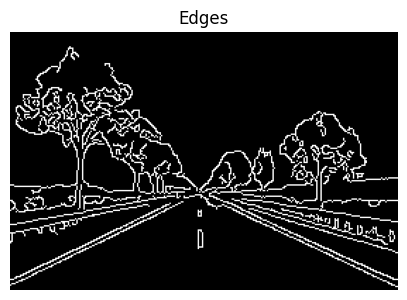

In [24]:
# Apply Canny edge detection
edges = cv2.Canny(blurred_image, 50, 150)  # Adjust the thresholds as needed

# Display the edges
plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap='gray')
plt.title('Edges')
plt.axis('off')
plt.show()

## Define a region of interest

### Subtask:
Focus on the area where lanes are expected to be.


**Reasoning**:
Get the dimensions of the edges image, define the vertices for the region of interest polygon, create a blank mask, fill the polygon in the mask, and apply the mask to the edges image.



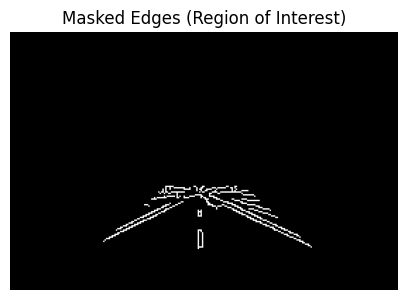

In [25]:
# Get the dimensions of the edges image
height, width = edges.shape[:2]

# Define the vertices of the region of interest polygon
# These coordinates are approximate and may need adjustment based on the image
vertices = np.array([
    [(int(width * 0.1), height),
     (int(width * 0.4), int(height * 0.6)),
     (int(width * 0.6), int(height * 0.6)),
     (int(width * 0.9), height)]
], dtype=np.int32)

# Create a blank mask image
mask = np.zeros_like(edges)

# Fill the polygon on the mask with white color (255)
cv2.fillPoly(mask, vertices, 255)

# Apply the mask to the edges image
masked_edges = cv2.bitwise_and(edges, mask)

# Display the masked edges
plt.figure(figsize=(5, 5))
plt.imshow(masked_edges, cmap='gray')
plt.title('Masked Edges (Region of Interest)')
plt.axis('off')
plt.show()

## Apply hough transform

### Subtask:
Detect lines within the region of interest.


**Reasoning**:
Apply the Hough Transform to detect lines in the masked edge image.



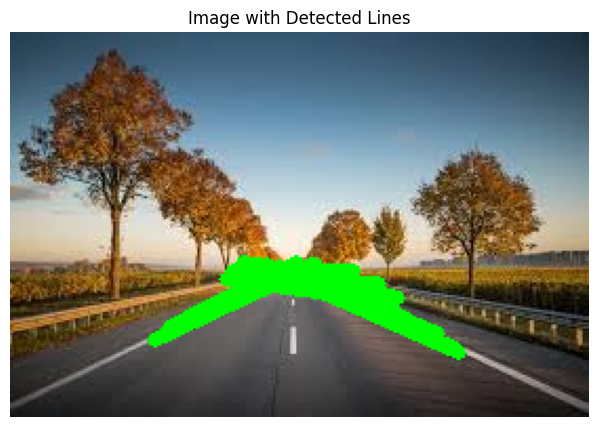

In [26]:
import numpy as np

# Apply the Hough Transform to detect lines
lines = cv2.HoughLinesP(masked_edges, rho=1, theta=np.pi/180, threshold=20, minLineLength=20, maxLineGap=300)

# Display the detected lines (optional - for visualization)
line_image = np.copy(image)  # Create a copy of the original image

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 5)  # Draw lines in green

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Detected Lines')
plt.axis('off')
plt.show()

## Filter and average lane lines

### Subtask:
Identify and average the lines that likely represent the lanes.


**Reasoning**:
Implement steps 1-6 of the subtask to classify and filter the detected lines into left and right lane lines based on their slopes and store their coordinates.



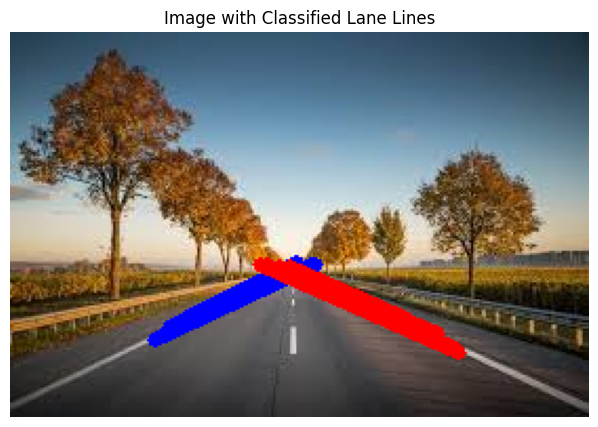

In [27]:
# Create empty lists to store the coordinates of the left and right lane lines
left_lane_lines = []
right_lane_lines = []

# Threshold for filtering out near-horizontal lines (adjust as needed)
slope_threshold = 0.3

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        # Calculate the slope of the line, avoiding division by zero
        if (x2 - x1) != 0:
            slope = (y2 - y1) / (x2 - x1)
        else:
            slope = float('inf') # Handle vertical lines

        # Classify the line as a left or right lane line based on its slope
        # Filter out lines that are likely outliers based on their slope
        if abs(slope) > slope_threshold:
            if slope < 0:  # Negative slope for left lane
                left_lane_lines.append((x1, y1, x2, y2))
            else:  # Positive slope for right lane
                right_lane_lines.append((x1, y1, x2, y2))

# Display the classified lines (optional - for visualization)
classified_line_image = np.copy(image)

for line in left_lane_lines:
    x1, y1, x2, y2 = line
    cv2.line(classified_line_image, (x1, y1), (x2, y2), (255, 0, 0), 5) # Draw left lines in blue

for line in right_lane_lines:
    x1, y1, x2, y2 = line
    cv2.line(classified_line_image, (x1, y1), (x2, y2), (0, 0, 255), 5) # Draw right lines in red

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(classified_line_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Classified Lane Lines')
plt.axis('off')
plt.show()

**Reasoning**:
Implement steps 7-10 of the subtask to calculate the average slope and y-intercept for the left and right lane lines, determine the endpoints of the averaged lines within the region of interest, and store the calculated endpoints.



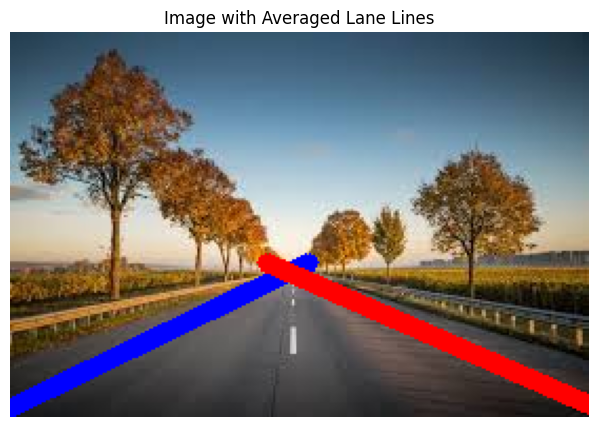

In [28]:
# Helper function to calculate slope and intercept
def calculate_slope_intercept(lines):
    if not lines:
        return None, None

    slopes = []
    intercepts = []
    for x1, y1, x2, y2 in lines:
        # Avoid division by zero for vertical lines, though they should be filtered by slope_threshold
        if (x2 - x1) != 0:
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1
            slopes.append(slope)
            intercepts.append(intercept)

    if slopes and intercepts:
        average_slope = np.mean(slopes)
        average_intercept = np.mean(intercepts)
        return average_slope, average_intercept
    else:
        return None, None

# Helper function to calculate line endpoints based on slope, intercept, and y-coordinates
def calculate_endpoints(y1, y2, slope, intercept):
    if slope is None or intercept is None:
        return None

    # Avoid division by zero if slope is near zero
    if abs(slope) < 1e-6: # Use a small threshold to check for near-zero slope
        return None

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return x1, y1, x2, y2

# Calculate average slope and intercept for left and right lanes
left_lane_slope, left_lane_intercept = calculate_slope_intercept(left_lane_lines)
right_lane_slope, right_lane_intercept = calculate_slope_intercept(right_lane_lines)

# Determine the y-coordinates for the endpoints (bottom of the image and top of the region of interest)
# These y-coordinates should correspond to the vertices defined earlier for the region of interest
# For simplicity, let's use the bottom of the image and a fixed upper y-coordinate.
# A more robust approach would use the actual y-coordinates from the region of interest vertices.
y1 = height # Bottom of the image
y2 = int(height * 0.6) # Approximately the top of the region of interest

# Store the calculated endpoints for the averaged left and right lane lines
averaged_left_lane = None
if left_lane_slope is not None and left_lane_intercept is not None:
     averaged_left_lane = calculate_endpoints(y1, y2, left_lane_slope, left_lane_intercept)


averaged_right_lane = None
if right_lane_slope is not None and right_lane_intercept is not None:
    averaged_right_lane = calculate_endpoints(y1, y2, right_lane_slope, right_lane_intercept)

# Display the averaged lane lines (optional - for visualization)
averaged_line_image = np.copy(image)

if averaged_left_lane is not None:
    x1, y1, x2, y2 = averaged_left_lane
    cv2.line(averaged_line_image, (x1, y1), (x2, y2), (255, 0, 0), 8) # Draw averaged left line in blue

if averaged_right_lane is not None:
    x1, y1, x2, y2 = averaged_right_lane
    cv2.line(averaged_line_image, (x1, y1), (x2, y2), (0, 0, 255), 8) # Draw averaged right line in red


plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(averaged_line_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Averaged Lane Lines')
plt.axis('off')
plt.show()

## Draw lane lines

### Subtask:
Draw the detected lane lines on a blank image.


**Reasoning**:
Draw the detected lane lines on a blank image using the averaged lane line coordinates.



In [29]:
import numpy as np

# Create a blank image with the same dimensions as the original image
lane_image = np.zeros_like(image)

# Draw the left lane line if it was detected
if averaged_left_lane is not None:
    x1, y1, x2, y2 = averaged_left_lane
    cv2.line(lane_image, (x1, y1), (x2, y2), (0, 255, 0), 10) # Draw in green with thickness 10

# Draw the right lane line if it was detected
if averaged_right_lane is not None:
    x1, y1, x2, y2 = averaged_right_lane
    cv2.line(lane_image, (x1, y1), (x2, y2), (0, 255, 0), 10) # Draw in green with thickness 10

## Combine images

### Subtask:
Overlay the detected lane lines onto the original image.


**Reasoning**:
Overlay the detected lane lines onto the original image using cv2.addWeighted.



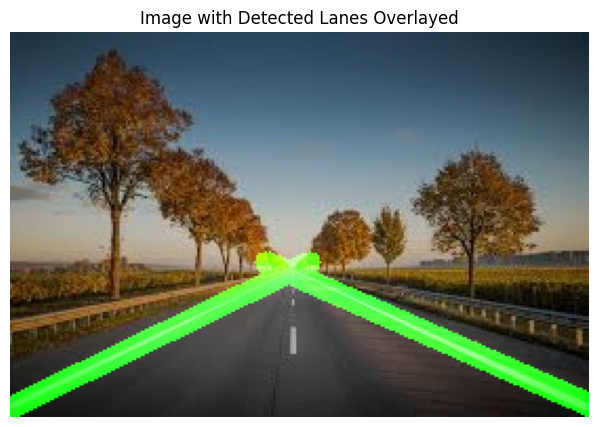

In [30]:
# Overlay the lane lines onto the original image
result_image = cv2.addWeighted(image, 0.8, lane_image, 1, 0)

# Display the final result
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Detected Lanes Overlayed')
plt.axis('off')
plt.show()

## Display the result

### Subtask:
Show the original image with the detected lanes.


**Reasoning**:
Display the result_image using matplotlib.pyplot with the correct color format, title, and no axes.



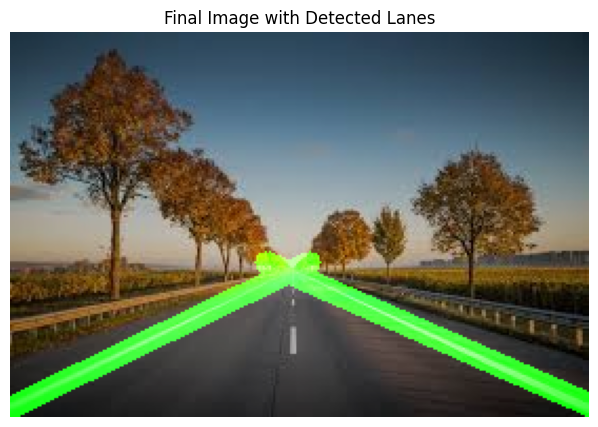

In [31]:
# Display the final result
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title('Final Image with Detected Lanes')
plt.axis('off')
plt.show()

## Summary:

### Data Analysis Key Findings

*   Gaussian blur was successfully applied to reduce noise in the grayscale image.
*   Canny edge detection was used to identify edges in the blurred image.
*   A polygonal region of interest was defined and applied to the edge-detected image to focus on the relevant area.
*   The Hough Transform successfully detected line segments within the region of interest.
*   Detected line segments were classified into left and right lane candidates based on their slope and averaged to represent each lane with a single line.
*   The averaged lane lines were drawn on a blank image.
*   The image with the drawn lane lines was successfully overlaid onto the original image.
*   The final image with detected lanes was displayed.

### Insights or Next Steps

*   The current region of interest definition is based on fixed proportions of the image dimensions. For better robustness across different image perspectives, consider dynamically adjusting the region of interest based on characteristics of the detected lines or using a more advanced perspective transformation.
*   The lane line detection could be improved by implementing a more sophisticated filtering and averaging process, possibly incorporating Kalman filters or other tracking methods for video streams to maintain consistency across frames.
